# Unified test: Laihmm + BetterStatesLaihmm

Loads data and parses into correct format. Runs query tests on `Laihmm` and `BetterStatesLaihmm`, along with visualization. *Note: `matplotlib` and `ipykernel` are not listed as requirements in `requirements.txt`. As such, to run all cells in this file, those packages will need to be installed. If this is being run from datahub, all requirements should be satisfied already.*

In [1]:
import numpy as np
from model import Laihmm, BetterStatesLaihmm

### Load and process data

In [3]:
#load gt data from npz file
print("loading ref genotypes (this is a really big file)")
with np.load("data/chr1_hmm_data_phased.npz") as data:
    ref_haplotypes = data["ref_hap0"]

#load allele freqs (for base model) from tsv
print("loading allele frequencies")
freqs = np.genfromtxt(
    "data/chr1_allele_freqs.tsv",
    delimiter="\t",
    names=True,
    dtype=None,
    encoding=None,
)

#assign CEU and YRI freqs
ceu_freqs = freqs["freq_CEU"]
yri_freqs = freqs["freq_YRI"]

#load sample metadata from 1kg tsv file
print("loading population data")
kg_samples = np.genfromtxt(
    "data/igsr_samples.tsv",
    delimiter="\t",
    names=True,
    dtype=None,
    encoding=None,
)

#get every sample
print("separating ceu and yri samples")
with open("data/ref_samples.txt") as f:
    samples = [line.strip() for line in f]

#make sample population map
sample_to_pop = dict(
    zip(kg_samples["Sample_name"], kg_samples["Population_code"])
)

#isolate CEU and YRI samples
ceu_samples = []
yri_samples = []

for i, sample in enumerate(samples):
    code = sample_to_pop.get(sample)
    if code == "CEU":
        ceu_samples.append(i)
    elif code == "YRI":
        yri_samples.append(i)

loading ref genotypes (this is a really big file)
loading allele frequencies
loading population data
separating ceu and yri samples


We need to generate an emission matrix for the base Laihmm model - admiteddly a flaw in design

In [4]:
#arbitrarily choose ceu sample to test against
#this test is supposed to be incredibly trivial - we should see VERY high accuracy
print("assigning example sample - first CEU index")
example_sample = ceu_samples[0]
haplotype = ref_haplotypes[:, example_sample]

#make emission matrix for base model - only cares about allele frequencies
print("generating emission matrix")
n_snps = haplotype.shape[0]
emission_matrix_trivial = np.zeros((2, n_snps))

mask0 = haplotype == 0
mask1 = haplotype == 1

emission_matrix_trivial[0, mask0] = 1 - ceu_freqs[mask0]
emission_matrix_trivial[0, mask1] = ceu_freqs[mask1]

emission_matrix_trivial[1, mask0] = 1 - yri_freqs[mask0]
emission_matrix_trivial[1, mask1] = yri_freqs[mask1]

assigning example sample - first CEU index
generating emission matrix


Also load query data and generate emission matrix for it as well. The query data was generating using haptools to simulate admixture between CEU and YRI populations

In [5]:
#now we re-generate the emission matrix for our admixed (query) sample
print("loading query data")
with np.load("data/chr1_hmm_data_phased.npz") as data:
    query_haplotypes = data["query_hap0"]
    positions = data["positions"]

print("assigning query sample - first index")
haplotype = query_haplotypes[:, 0]

#make emission matrix for base model - only cares about allele frequencies
print("generating emission matrix")
n_snps = haplotype.shape[0]
emission_matrix = np.zeros((2, n_snps))

mask0 = haplotype == 0
mask1 = haplotype == 1

emission_matrix[0, mask0] = 1 - ceu_freqs[mask0]
emission_matrix[0, mask1] = ceu_freqs[mask1]

emission_matrix[1, mask0] = 1 - yri_freqs[mask0]
emission_matrix[1, mask1] = yri_freqs[mask1]

print("generating ground truth for query sample")
with open("data/sim_admixed_chr1.bp") as f:
    recomb_positions = []
    f.readline()
    for line in f:
        if len(line.split()) < 4:
            break
        line = line.split()
        recomb_positions.append((line[0], int(line[2])))

ancestry_map = {"CEU": 0, "YRI": 1}
bps = np.array([p for _, p in recomb_positions])
labels = np.array([ancestry_map[a] for a, _ in recomb_positions])
#use searchsorted to get number of breakpoints before each snp
segment_indices = np.searchsorted(bps, positions, side="right")
#then assign ancestry
ground_truth = labels[segment_indices]
assert ground_truth.shape == (n_snps,)

loading query data
assigning query sample - first index
generating emission matrix
generating ground truth for query sample


### `Laihmm`

Now we can simply initialize our HMM with the emission matrix we generated and call the predict function with no parameters. We initialize the transition probability to the default here (0.001), but the model is fast enough so it can be freely changed at little cost.

In [6]:
#run hmm
print("running HMM")
model = Laihmm(emission_matrix_trivial, transition_prob=0.001)
predictions = model.predict()

#evaluate basic accuracy - no advanced statistics here because this is more of a
#proof of concept test
print('\nRESULTS FOR "100%" CEU BACKGROUND:')
predictions = np.array(predictions)
errors = np.sum(predictions != 0)
accuracy = (len(predictions) - errors) / len(predictions)
print(f"accuracy: {accuracy}")
print(f"number of errors: {errors}")

running HMM


  0%|          | 0/739655 [00:00<?, ?it/s]

100%|██████████| 739655/739655 [00:07<00:00, 96100.65it/s]



RESULTS FOR "100%" CEU BACKGROUND:
accuracy: 0.9938620115296841
number of errors: 4540


Then run on admixed. Again, since we re-initialize the model, the transition probability can be adjusted freely. There also exists a function to update the transition probability in the Laihmm class.

In [7]:
print("running HMM for admixed individual")
model = Laihmm(emission_matrix, transition_prob=0.001)
predictions = model.predict()

print("\nRESULTS FOR ADMIXED:")
predictions = np.array(predictions)
errors = np.sum(predictions != ground_truth)
accuracy = (len(predictions) - errors) / len(predictions)
print(f"accuracy: {accuracy}")
print(f"number of errors: {errors}")

running HMM for admixed individual


100%|██████████| 739655/739655 [00:07<00:00, 93891.85it/s]



RESULTS FOR ADMIXED:
accuracy: 0.9905591247823312
number of errors: 6983


### `BetterStatesLaihmm`

In [8]:
print("getting reference panel for better states model")
ref_indices = np.concatenate((ceu_samples, yri_samples))
#transpose to get shape (num_donors, num_snps)
panel = ref_haplotypes[:, ref_indices].T
ancestries = np.concatenate((np.full(len(ceu_samples), 0), np.full(len(yri_samples), 1)))

getting reference panel for better states model


In [10]:
print("running BetterStatesLaihmm on admixed target")
model = BetterStatesLaihmm(panel, ancestries)
ancestry_sequence = np.array(model.predict(haplotype))

# Evaluate
print("\nRESULTS FOR ADMIXED WITH BETTER STATES MODEL:")
errors = np.sum(ancestry_sequence != ground_truth)
accuracy = (len(ancestry_sequence) - errors) / len(ancestry_sequence)
print(f"accuracy: {accuracy}")
print(f"number of errors: {errors}")

running BetterStatesLaihmm on admixed target


100%|██████████| 739655/739655 [00:49<00:00, 14971.41it/s]



RESULTS FOR ADMIXED WITH BETTER STATES MODEL:
accuracy: 0.9893463988665001
number of errors: 7880


We observe, in this case, a marginally lower accuracy on the query sample using `BetterStatesLaihmm` than when using the basic `Laihmm` model. This could be for a variety of reasons.
1. It's possible that `Laihmm` could perform better in simpler situations. This example assumes admixture between only two populations, which are quite different.
2. Allele frequencies may encode more information in this context than donor haplotypes. Though it was a goal, we did not manage to get to the point of utilizing emissions which encode allele frequencies in combination with a more advanced state space (which is what FLARE does). As such, in this somewhat trivial example, it's entirely possible that because the populations are so different, the difference in their allele frequencies is enough to produce high accuracy.
    - We suspect that if a third ancestry which was some intermediate between the two was included in the emission matrix for the `Laihmm` model, it's accuracy would decrease substantially.
    - We weren't able to fully implement frequency based emissions in `BetterStatesLaihmm` primarily due to time constraints. Calculating allele frequencies for just two populations was already time consuming.

### Visualization

Viterbi path for `BetterStatesLaihmm` and `Laihmm` relative to the ground truth path.

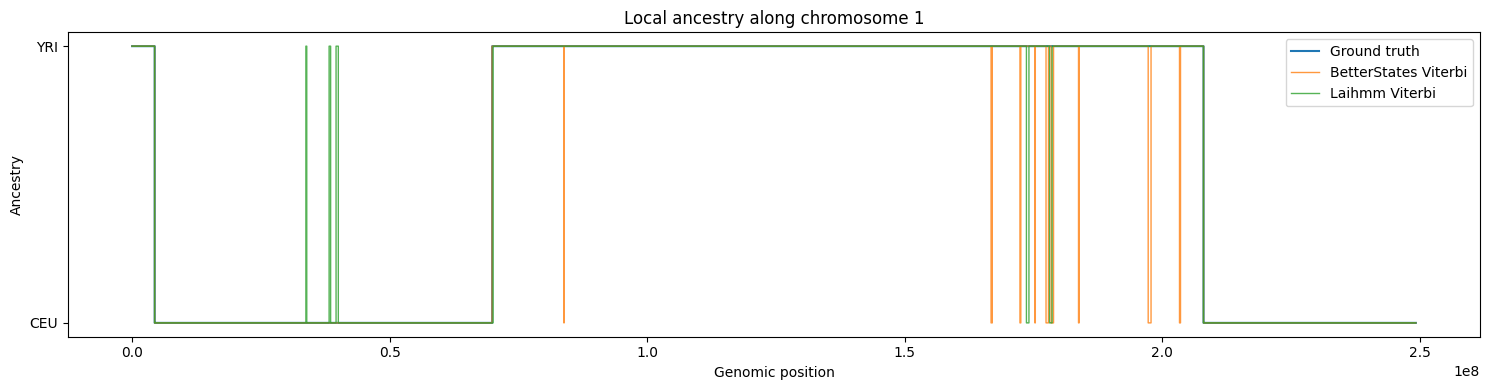

In [15]:
import matplotlib.pyplot as plt

n_snps_total = len(ground_truth)
start = 0

x = positions

plt.figure(figsize=(15, 4))
plt.step(x, ground_truth, where="post", label="Ground truth", linewidth=1.5)
plt.step(x, ancestry_sequence, where="post", label="BetterStates Viterbi", linewidth=1, alpha=0.8)
plt.step(x, predictions, where="post", label="Laihmm Viterbi", linewidth=1, alpha=0.8)

plt.yticks([0, 1], ["CEU", "YRI"])
plt.xlabel("Genomic position")
plt.ylabel("Ancestry")
plt.title("Local ancestry along chromosome 1")
plt.legend(loc="upper right")
plt.tight_layout()

We can see from this figure that most errors form very small tracts. The FLARE model utilizes genetic distance (in Morgans) as part of the transition probability calculation. If time permitted, a similar implementation may have prevented these small errors, since genetic distance would make transitioning rare for nearby SNPs, and more likely when further apart. You would not expect to see this transition pattern due to natural admixture.

Reference panel counts by ancestry (0=CEU, 1=YRI):
  CEU (0): 99
  YRI (1): 108


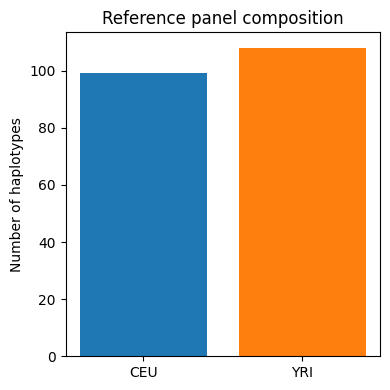

In [ ]:
#ref panel analysis
unique, counts = np.unique(ancestries, return_counts=True)
panel_counts = dict(zip(unique, counts))

print("Reference panel counts by ancestry (0=CEU, 1=YRI):")
for anc, cnt in panel_counts.items():
    label = "CEU" if anc == 0 else "YRI"
    print(f"  {label} ({anc}): {cnt}")

plt.figure(figsize=(4, 4))
labels = ["CEU", "YRI"]
values = [panel_counts.get(0, 0), panel_counts.get(1, 0)]
plt.bar(labels, values, color=["tab:blue", "tab:orange"])
plt.ylabel("Number of haplotypes")
plt.title("Reference panel composition")
plt.tight_layout()
plt.show()

Our reference panel is slightly biased towards YRI, but not to an incredible degree. FLARE normalizes the provided reference panel such that there are no biases towards one population over the other. Currently, ours does not.

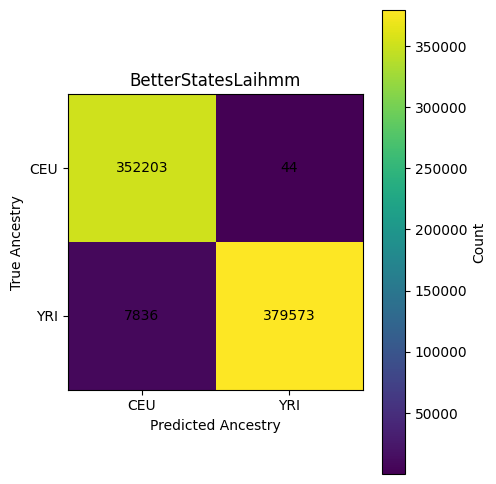

CEU accuracy: 0.9999
YRI accuracy: 0.9798


In [17]:
#confusion matrix
confusion = np.zeros((2, 2), dtype=int)
for t, p in zip(ground_truth, ancestry_sequence):
    confusion[int(t), int(p)] += 1

labels = ["CEU", "YRI"]

plt.figure(figsize=(5, 5))
plt.imshow(confusion)

plt.title("BetterStatesLaihmm")
plt.xlabel("Predicted Ancestry")
plt.ylabel("True Ancestry")

plt.xticks(np.arange(2), labels)
plt.yticks(np.arange(2), labels)

#annotate counts
for i in range(2):
    for j in range(2):
        plt.text(j, i, confusion[i, j], ha="center", va="center")

plt.colorbar(label="Count")
plt.tight_layout()
plt.show()

#accuracy per ancestry
for anc in [0, 1]:
    mask = ground_truth == anc
    if np.any(mask):
        acc_anc = np.mean(ancestry_sequence[mask] == ground_truth[mask])
        label = "CEU" if anc == 0 else "YRI"
        print(f"{label} accuracy: {acc_anc:.4f}")

YRI seems to be the most mispredicted ancestry. This could be due to two possible reasons
1. Our admixed individual had mostly YRI ancestry, and as such there are more opportunities. This seems unlikely, because proportionally the difference in YRI vs CEU contributed ancestry doesn't account for the difference in errors.
2. More likely (we hypothesize) is that YRI is a more genetically diverse population than CEU, and as such it becomes easier to mistake YRI ancestry for CEU, but difficult to mistake CEU for YRI.

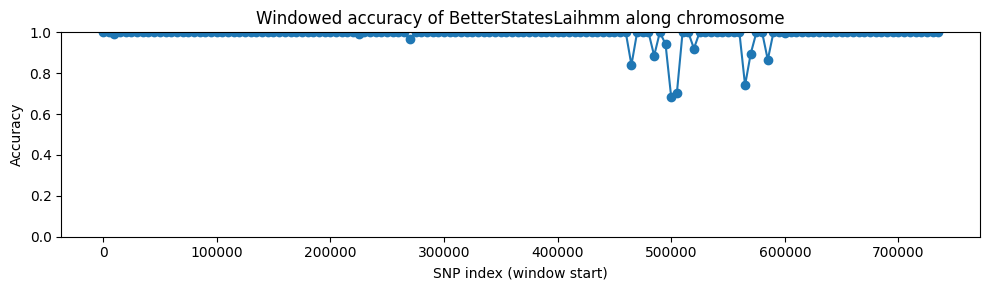

In [ ]:
#windowed accuracy along the chromosome
window_size = 5000
n = len(ground_truth)
window_starts = np.arange(0, n, window_size)
window_acc = []
for s in window_starts:
    e = min(n, s + window_size)
    if e - s == 0:
        continue
    window_acc.append(np.mean(ancestry_sequence[s:e] == ground_truth[s:e]))

plt.figure(figsize=(10, 3))
plt.plot(window_starts[: len(window_acc)], window_acc, marker="o", linestyle="-")
plt.ylim(0, 1)
plt.xlabel("SNP index (window start)")
plt.ylabel("Accuracy")
plt.title("Windowed accuracy of BetterStatesLaihmm along chromosome")
plt.tight_layout()
plt.show()

Most errors accumulate in a specific portion of the chromosome. This could potentially be due to SNPs which are shared in the two populations at this position, or perhaps a diverse area. Regardless, the clustering of errors suggests a pattern beyond just random errors.